In [ ]:
import sys
sys.path.insert(0, "../src")
from backtester.data.loader import load_ticker

df = load_ticker("RELIANCE.NS", "2020-01-01", "2025-12-31")
print(df.head())
print(df.shape)

In [ ]:
print("Columns:", df.columns.tolist())
print("Index type:", type(df.index))
print("\nFirst row:")
print(df.iloc[0])

In [ ]:
# Plot the close price
import matplotlib.pyplot as plt

df["Close"].plot(figsize=(12, 6), title="Reliance Close Price")
plt.show()

# Are there any missing values?
print("Missing values per column:")
print(df.isnull().sum())

# Any zero or negative prices? (would be bad)
print("\nNon-positive close prices:", (df["Close"] <= 0).sum())

In [ ]:
from backtester.data.loader import load_multiple_tickers

tickers = ["RELIANCE.NS", "TCS.NS", "INFY.NS"]
data = load_multiple_tickers(tickers, "2023-01-01", "2024-12-31")

print(f"Loaded {len(data)} stocks!")
print(data["TCS.NS"].head())

In [ ]:
#reading a parquet downloaded file, for  faster experience
import time
import sys
sys.path.insert(0, "../src")
from backtester.data.loader import load_ticker_with_cache
# First time: downloads (slow)
start_time = time.time()
df1 = load_ticker_with_cache("RELIANCE.NS", "2020-01-01", "2025-12-31")
print(f"First load: {time.time() - start_time:.2f} seconds")

# Second time: from disk (fast)
start_time = time.time()
df2 = load_ticker_with_cache("RELIANCE.NS", "2020-01-01", "2025-12-31")
print(f"Second load: {time.time() - start_time:.2f} seconds")


In [9]:
"""GETTING CLOSE PRICES IN A USEFUL SHAPE-->having a single DataFrame with all close prices of different stocks"""
import sys
sys.path.insert(0, "../src")
from backtester.data.loader import get_close_prices
from backtester.data.loader import load_multiple_tickers

data = load_multiple_tickers(["RELIANCE.NS", "TCS.NS", "INFY.NS"], "2022-01-01", "2024-12-31")
close_prices = get_close_prices(data)

print(close_prices.head())
print(f"\nShape: {close_prices.shape}")

Loading RELIANCE.NS ...
Loading RELIANCE.NS from cache
Loading TCS.NS ...
Loading TCS.NS from cache
Loading INFY.NS ...
Loading INFY.NS from cache
            RELIANCE.NS       TCS.NS      INFY.NS
Date                                             
2023-01-02  1175.889648  2932.793701  1397.702148
2023-01-03  1167.284546  2977.665771  1396.372437
2023-01-04  1149.709595  2980.633057  1370.921997
2023-01-05  1147.655396  2977.440674  1352.946167
2023-01-06  1158.086182  2887.922607  1328.458984

Shape: (490, 3)


In [10]:
"""HAD GOT A BUG HERE

The data was loading from previous Chache , and was very frustrating.
Claude helped me in debugging"""

'HAD GOT A BUG HERE\n\nThe data was loading from previous Chache , and was very frustrating.\nClaude helped me in debugging'

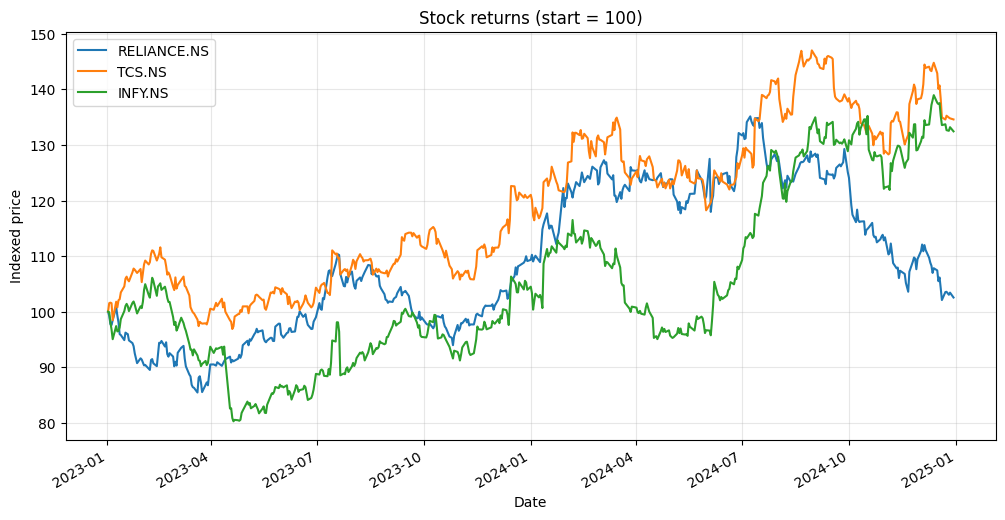

In [11]:
# Normalize prices so they all start at 100 — makes them comparable
normalized = close_prices/ close_prices.iloc[0] * 100
"""Why divide by prices.iloc[0] and multiply by 100? It rescales every stock so that day 1 = 100. Now you can see relative performance — which stock grew more, which lagged. If you plotted raw prices, Reliance at ₹2500 and Infosys at ₹1500 would look completely different even if they had the same returns."""

normalized.plot(figsize=(12, 6), title="Stock returns (start = 100)")
import matplotlib.pyplot as plt
plt.ylabel("Indexed price")
plt.grid(True, alpha=0.3)
plt.show()